<a href="https://colab.research.google.com/github/TAUforPython/Reservoir-Computing/blob/master/example%20RNN%20ESN%20LSM%20for%20sine%20generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Libraries imported and seeds set

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import random

# Set random seeds for reproducibility
seed_value = 37
np.random.seed(seed_value)
random.seed(seed_value)

# Model of Dynamic System (Ground Truth Signal)

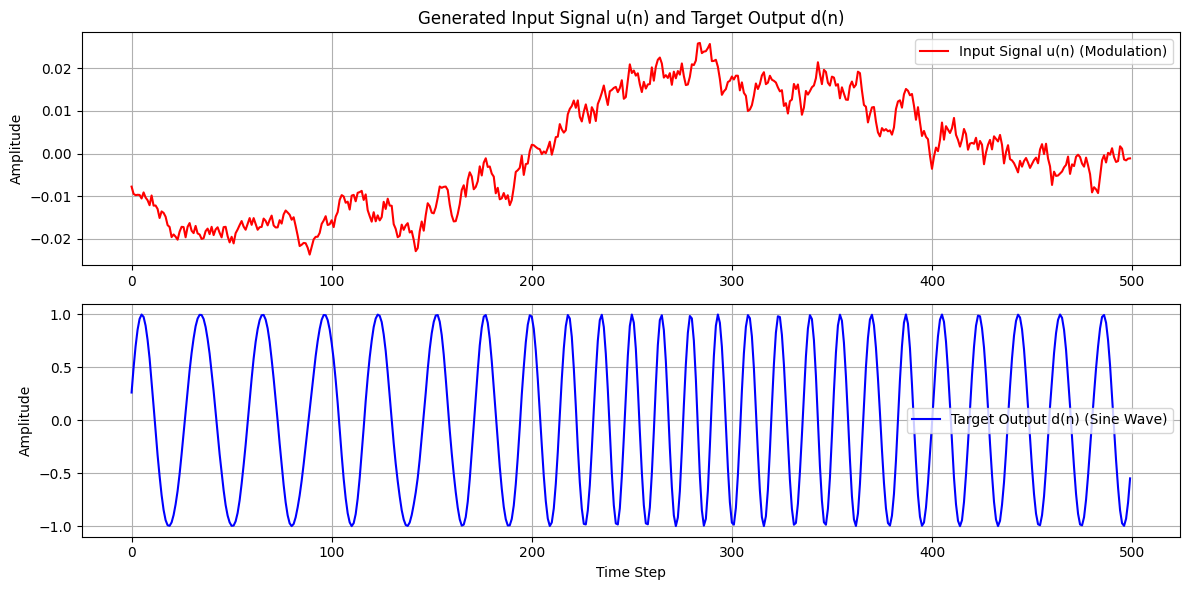

Generated 2000 time steps of data. Modulation: True


In [14]:
# We'll create a tunable sine wave generator as the ground truth.
# The frequency can be adjusted by an input signal u(n).

def generate_sine_data(length, base_freq=0.05, freq_modulation=False, u_signal=None):
    """
    Generates a sine wave signal. Can be fixed frequency or modulated by an input signal u(n).

    Args:
        length (int): Number of time steps to generate.
        base_freq (float): Base frequency of the sine wave (if not modulated).
        freq_modulation (bool): If True, modulate frequency using u_signal.
        u_signal (numpy.ndarray, optional): Input signal to modulate frequency. Shape (length, 1).

    Returns:
        numpy.ndarray: The generated sine wave signal. Shape (length, 1).
    """
    n = np.arange(length)
    if freq_modulation and u_signal is not None:
        # Interpret u_signal as a frequency offset multiplier
        # Clamp u_signal to a reasonable range to avoid extreme frequencies
        u_clamped = np.clip(u_signal.flatten(), -0.1, 0.1)
        freq_signal = base_freq + u_clamped
        # Integrate frequency to get phase for smooth modulation
        phase = np.cumsum(2 * np.pi * freq_signal)
        signal = np.sin(phase)
    else:
        signal = np.sin(2 * np.pi * base_freq * n)

    return signal.reshape(-1, 1) # Shape (length, 1)

# --- Configuration ---
total_length = 2000
base_frequency = 0.05
freq_modulation = True # Set to True for the tunable generator example

# --- Generate Input Signal u(n) ---
# For modulation, we need an input signal u(n)
if freq_modulation:
    # Create a slowly varying input signal for frequency modulation
    u_raw = (np.random.uniform(-0.5, 0.5, total_length))
    # Smooth the input signal to avoid abrupt frequency changes
    window_len = 200
    u_smooth = np.convolve(u_raw, np.ones(window_len)/window_len, mode='same')
    u_input = u_smooth.reshape(-1, 1) # Shape (total_length, 1)
else:
    u_input = np.zeros((total_length, 1)) # Constant input if no modulation

# --- Generate Target Output Signal d(n) ---
d_target = generate_sine_data(total_length, base_freq=base_frequency, freq_modulation=freq_modulation, u_signal=u_input)

# Plot the generated signals
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
if freq_modulation:
    plt.plot(u_input[:500], label='Input Signal u(n) (Modulation)', color='red')
plt.title('Generated Input Signal u(n) and Target Output d(n)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(d_target[:500], label='Target Output d(n) (Sine Wave)', color='blue')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Generated {total_length} time steps of data. Modulation: {freq_modulation}")

# Train Echo-State-Network

In [15]:

# We'll use the first part for training and the latter part for testing.
# We also need to account for initial transient washout time (T0) as mentioned in the text.

train_length = int(0.7 * total_length)
test_length = total_length - train_length
T0 = 100 # Initial washout time to discard

# --- Prepare input and target data ---
u_full = u_input
d_full = d_target

u_train = u_full[:train_length]
d_train = d_full[:train_length]
u_test = u_full[train_length:]
d_test = d_full[train_length:]

print(f"Train length: {train_length}, Test length: {test_length}")
print(f"Training will discard first {T0} steps as transient.")

Train length: 1400, Test length: 600
Training will discard first 100 steps as transient.


--- Training ESN ---
ESN fitted. Wout shape: (1, 101)
ESN Test MSE: 0.544570


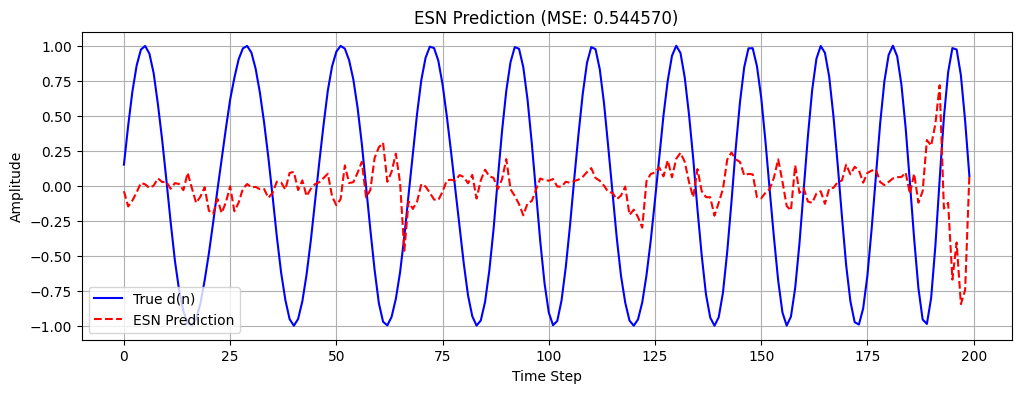

In [16]:
class EchoStateNetwork:
    def __init__(self, n_inputs, n_reservoir, n_outputs, spectral_radius=0.95,
                 input_scaling=1.0, reservoir_scaling=1.0, leak_rate=1.0, random_state=42):
        """
        Initializes the Echo State Network.

        Args:
            n_inputs (int): Number of input units.
            n_reservoir (int): Number of reservoir units.
            n_outputs (int): Number of output units.
            spectral_radius (float): Desired spectral radius of the reservoir weight matrix.
            input_scaling (float): Scaling factor for input weights.
            reservoir_scaling (float): Scaling factor for reservoir weights (after spectral radius adjustment).
            leak_rate (float): Leaking rate for the reservoir state update (0 < leak_rate <= 1).
            random_state (int): Seed for random number generation.
        """
        self.n_inputs = n_inputs
        self.n_reservoir = n_reservoir
        self.n_outputs = n_outputs
        self.input_scaling = input_scaling
        self.reservoir_scaling = reservoir_scaling
        self.leak_rate = leak_rate
        self.random_state = random_state

        # Set random seed for numpy within the class initialization
        np.random.seed(self.random_state)

        # Initialize reservoir weights W (NxN)
        # Generate random matrix
        W = np.random.rand(self.n_reservoir, self.n_reservoir) - 0.5 # Values between -0.5 and 0.5
        # Adjust spectral radius
        eigenvalues, _ = np.linalg.eig(W)
        current_spectral_radius = np.max(np.abs(eigenvalues))
        W = (W / current_spectral_radius) * spectral_radius
        self.W = W * self.reservoir_scaling

        # Initialize input weights Win (NxK)
        # Ensure some inputs connect to the reservoir
        Win = (np.random.rand(self.n_reservoir, self.n_inputs) - 0.5) * 2 * self.input_scaling
        self.Win = Win

        # No explicit output feedback (Wback) in this simple setup for prediction
        # Initialize output weights Wout (Lx(N+K+L))
        # We'll calculate this during training
        self.Wout = None

        # Initialize state
        self.x = np.zeros((self.n_reservoir, 1))

    def _update_state(self, u, y_prev=None):
        """
        Updates the reservoir state based on input u and potentially previous output y_prev.

        Args:
            u (numpy.ndarray): Input vector. Shape (n_inputs, 1).
            y_prev (numpy.ndarray, optional): Previous output vector. Shape (n_outputs, 1).

        Returns:
            numpy.ndarray: Updated reservoir state. Shape (n_reservoir, 1).
        """
        # Calculate the new state using the ESN update rule (1.6)
        # x(n+1) = (1 - leak_rate) * x(n) + leak_rate * f(W * x(n) + Win * u(n))
        # Using tanh as the activation function f
        pre_activation = np.dot(self.W, self.x) + np.dot(self.Win, u)
        new_x = np.tanh(pre_activation)

        # Apply leaking
        if self.leak_rate < 1.0:
            self.x = (1 - self.leak_rate) * self.x + self.leak_rate * new_x
        else:
            self.x = new_x # Standard update if leak_rate is 1.0

        return self.x

    def fit(self, u_data, d_data, T0=0):
        """
        Trains the ESN by calculating the output weights Wout.

        Args:
            u_data (numpy.ndarray): Training input data. Shape (T, n_inputs).
            d_data (numpy.ndarray): Training target output data. Shape (T, n_outputs).
            T0 (int): Number of initial time steps to discard.
        """
        T = u_data.shape[0]
        collected_states = []
        collected_targets = []

        # Reset state before training
        self.x = np.zeros((self.n_reservoir, 1))

        for t in range(T):
            u_t = u_data[t].reshape(-1, 1) # Shape (n_inputs, 1)
            d_t = d_data[t].reshape(-1, 1) # Shape (n_outputs, 1)

            # Update the reservoir state
            self._update_state(u_t)

            # Collect state and target after initial transient
            if t >= T0:
                # Concatenate [input, reservoir_state] -> [K, N]
                current_state_concat = np.vstack([u_t, self.x]) # Shape (K+N, 1)
                collected_states.append(current_state_concat.flatten())
                collected_targets.append(d_t.flatten())

        # Convert lists to numpy arrays
        M = np.array(collected_states) # Shape (T-T0, K+N)
        T_targets = np.array(collected_targets) # Shape (T-T0, L)

        # Calculate output weights using pseudoinverse
        # Wout = T_targets^T * M^+
        # where M^+ is the pseudoinverse of M
        # This minimizes ||M * Wout^T - T_targets^T||^2
        # Resulting Wout has shape (L, K+N)
        try:
            Wout_T = np.linalg.pinv(M) @ T_targets # Shape (K+N, L)
            self.Wout = Wout_T.T # Shape (L, K+N)
        except np.linalg.LinAlgError:
            print("Warning: Pseudoinverse failed, using least squares solution.")
            self.Wout, residuals, rank, s = np.linalg.lstsq(M, T_targets, rcond=None)
            self.Wout = self.Wout.T # Shape (L, K+N)

        print(f"ESN fitted. Wout shape: {self.Wout.shape}")

    def predict(self, u_data, initial_state=None):
        """
        Generates output sequence based on input sequence using trained weights.

        Args:
            u_data (numpy.ndarray): Input data for prediction. Shape (P, n_inputs).
            initial_state (numpy.ndarray, optional): Initial reservoir state. Shape (n_reservoir, 1).

        Returns:
            numpy.ndarray: Predicted output sequence. Shape (P, n_outputs).
        """
        if self.Wout is None:
            raise ValueError("Model must be fitted before prediction.")

        P = u_data.shape[0]
        predictions = np.zeros((P, self.n_outputs))

        # Optionally set initial state
        if initial_state is not None:
            self.x = initial_state
        else:
            # Reset state if not provided
            self.x = np.zeros((self.n_reservoir, 1))

        for t in range(P):
            u_t = u_data[t].reshape(-1, 1) # Shape (n_inputs, 1)

            # Update the reservoir state
            self._update_state(u_t)

            # Calculate output using trained weights
            # Concatenate [input, reservoir_state]
            state_concat = np.vstack([u_t, self.x]) # Shape (K+N, 1)
            y_t = self.Wout @ state_concat # Shape (L, 1)
            predictions[t] = y_t.flatten()

        return predictions


# --- Train ESN ---
print("--- Training ESN ---")
esn = EchoStateNetwork(
    n_inputs=1,
    n_reservoir=100, # As mentioned in the text for the tunable task
    n_outputs=1,
    spectral_radius=0.8, # As mentioned in the text
    input_scaling=1.0,
    reservoir_scaling=1.0,
    leak_rate=1.0, # Standard update
    random_state=42
)

esn.fit(u_train, d_train, T0=T0)

# --- Test ESN ---
y_pred_esn = esn.predict(u_test)

# Calculate MSE
mse_esn = mean_squared_error(d_test, y_pred_esn)
print(f"ESN Test MSE: {mse_esn:.6f}")

# Plot ESN Results
plt.figure(figsize=(12, 4))
plt.plot(d_test[:200], label='True d(n)', color='blue')
plt.plot(y_pred_esn[:200], label='ESN Prediction', color='red', linestyle='--')
plt.title(f'ESN Prediction (MSE: {mse_esn:.6f})')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# Train Liquid State Machine (LSM)


--- Training LSM-like Model ---
Initialized LSM-like model (using ESN structure for continuous signals).
ESN fitted. Wout shape: (1, 101)
LSM-like Test MSE: 0.538387


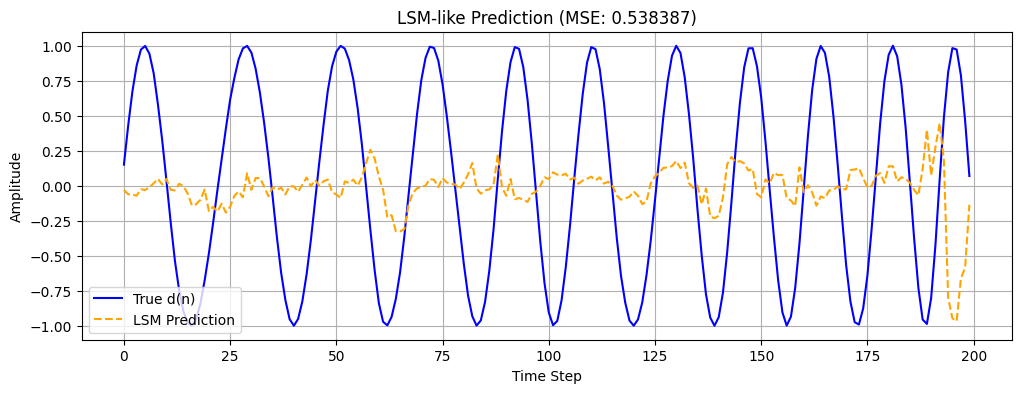

In [17]:
# Note: The provided text mentions LSMs as similar but developed independently.
# A full LSM implementation involves spiking neurons, which is significantly more complex.
# For this comparison task, we can consider a simplified, non-spiking version
# that behaves similarly to an ESN conceptually, using continuous activation.
# We'll reuse the ESN class structure, as the core idea of a fixed reservoir with trainable readout is shared.
# The main difference often lies in the neuron model (spiking vs. continuous) and connectivity patterns.
# For this exercise, we'll use the ESN class but refer to it as an LSM-like model for comparison.
# A true LSM would require a spiking neural network simulator.

class LiquidStateMachineLike(EchoStateNetwork): # Inherit from the EchoStateNetwork CLASS, not the instance 'esn'
    """
    A simplified model representing the concept of an LSM.
    In practice, a true LSM uses spiking neurons.
    This class is functionally identical to the ESN class for continuous signals.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs) # Call the parent class constructor
        print("Initialized LSM-like model (using ESN structure for continuous signals).")

# --- Train LSM ---
print("\n--- Training LSM-like Model ---")
lsm = LiquidStateMachineLike(
    n_inputs=1,
    n_reservoir=100,
    n_outputs=1,
    spectral_radius=0.8,
    input_scaling=1.0,
    reservoir_scaling=1.0,
    leak_rate=1.0,
    random_state=43 # Different seed
)

lsm.fit(u_train, d_train, T0=T0)

# --- Test LSM ---
y_pred_lsm = lsm.predict(u_test)

# Calculate MSE
mse_lsm = mean_squared_error(d_test, y_pred_lsm)
print(f"LSM-like Test MSE: {mse_lsm:.6f}")

# Plot LSM Results
plt.figure(figsize=(12, 4))
plt.plot(d_test[:200], label='True d(n)', color='blue')
plt.plot(y_pred_lsm[:200], label='LSM Prediction', color='orange', linestyle='--')
plt.title(f'LSM-like Prediction (MSE: {mse_lsm:.6f})')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# Train RNN Network


Using device: cpu
RNN Training Data Shape - X: (1390, 10, 1), y: (1390, 1)
RNN Test Data Shape - X: (590, 10, 1), y: (590, 1)

--- Training RNN ---
Epoch [20/100], Loss: 0.497093
Epoch [40/100], Loss: 0.496424
Epoch [60/100], Loss: 0.497248
Epoch [80/100], Loss: 0.499548
Epoch [100/100], Loss: 0.498490
RNN Training Complete.
RNN Test MSE: 0.499216


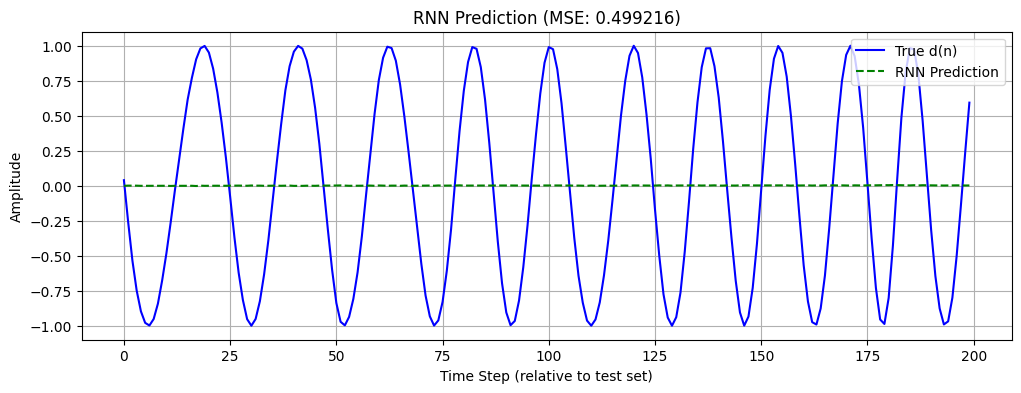

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class SimpleRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        # Use nn.RNN, nn.LSTM, or nn.GRU here. Let's use nn.RNN for simplicity.
        self.rnn = nn.RNN(input_size, hidden_size, num_layers=n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x, hidden=None):
        # x shape: (batch, seq_len, input_size)
        # hidden shape: (n_layers, batch, hidden_size)
        rnn_out, hidden = self.rnn(x, hidden)
        # We want the output for the last time step of the sequence
        output = self.fc(rnn_out[:, -1, :]) # Shape: (batch, output_size)
        return output, hidden

# --- Prepare data for PyTorch RNN ---
# We need to create sequences of inputs [u(t-lookback+1), ..., u(t)] to predict d(t)
def create_rnn_sequences(input_data, target_data, lookback):
    """
    Creates input/output pairs for sequence-to-one prediction for RNN.

    Args:
        input_data (numpy.ndarray): Input signal u(n). Shape (T, 1).
        target_data (numpy.ndarray): Target signal d(n). Shape (T, 1).
        lookback (int): Number of previous time steps to use as input.

    Returns:
        numpy.ndarray: Input sequences. Shape (T - lookback, lookback, 1).
        numpy.ndarray: Target outputs. Shape (T - lookback, 1).
    """
    X, y = [], []
    for i in range(lookback, len(input_data)): # Start from lookback to have enough history
        # Input sequence: u(n-lookback+1) to u(n)
        X.append(input_data[i-lookback:i])
        # Target: d(n)
        y.append(target_data[i])
    return np.array(X), np.array(y)

lookback_steps = 10

# Create sequences for training
X_train_rnn, y_train_rnn = create_rnn_sequences(u_train, d_train, lookback_steps)
# Create sequences for testing
X_test_rnn, y_test_rnn = create_rnn_sequences(u_test, d_test, lookback_steps)

print(f"RNN Training Data Shape - X: {X_train_rnn.shape}, y: {y_train_rnn.shape}")
print(f"RNN Test Data Shape - X: {X_test_rnn.shape}, y: {y_test_rnn.shape}")

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_rnn, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train_rnn, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test_rnn, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test_rnn, dtype=torch.float32).to(device)

# Create datasets and dataloaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# --- Initialize and Train RNN ---
print("\n--- Training RNN ---")
rnn_model = SimpleRNN(input_size=1, hidden_size=50, output_size=1, n_layers=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)

num_epochs = 100
rnn_losses = []
for epoch in range(num_epochs):
    rnn_model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # batch_X shape: (batch_size, lookback_steps, input_size=1)
        output, _ = rnn_model(batch_X)
        loss = criterion(output, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    rnn_losses.append(avg_loss)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}')

print("RNN Training Complete.")

# --- Test RNN ---
rnn_model.eval()
with torch.no_grad():
    # Use the test data
    y_pred_rnn_tensor, _ = rnn_model(X_test_tensor)
    y_pred_rnn = y_pred_rnn_tensor.cpu().numpy()

# Calculate MSE
mse_rnn = mean_squared_error(y_test_tensor.cpu().numpy(), y_pred_rnn)
print(f"RNN Test MSE: {mse_rnn:.6f}")

# Plot RNN Results (compare first 200 predictions)
plt.figure(figsize=(12, 4))
plt.plot(y_test_tensor.cpu().numpy()[:200], label='True d(n)', color='blue')
plt.plot(y_pred_rnn[:200], label='RNN Prediction', color='green', linestyle='--')
plt.title(f'RNN Prediction (MSE: {mse_rnn:.6f})')
plt.xlabel('Time Step (relative to test set)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

# Visualize Comparison (RNN, ESN, LSM)


--- Comparing Models on RNN Target Slice ---
Comparing on 590 test steps.
ESN MSE on comparison slice: 0.530315
LSM MSE on comparison slice: 0.526887
RNN MSE: 0.506372


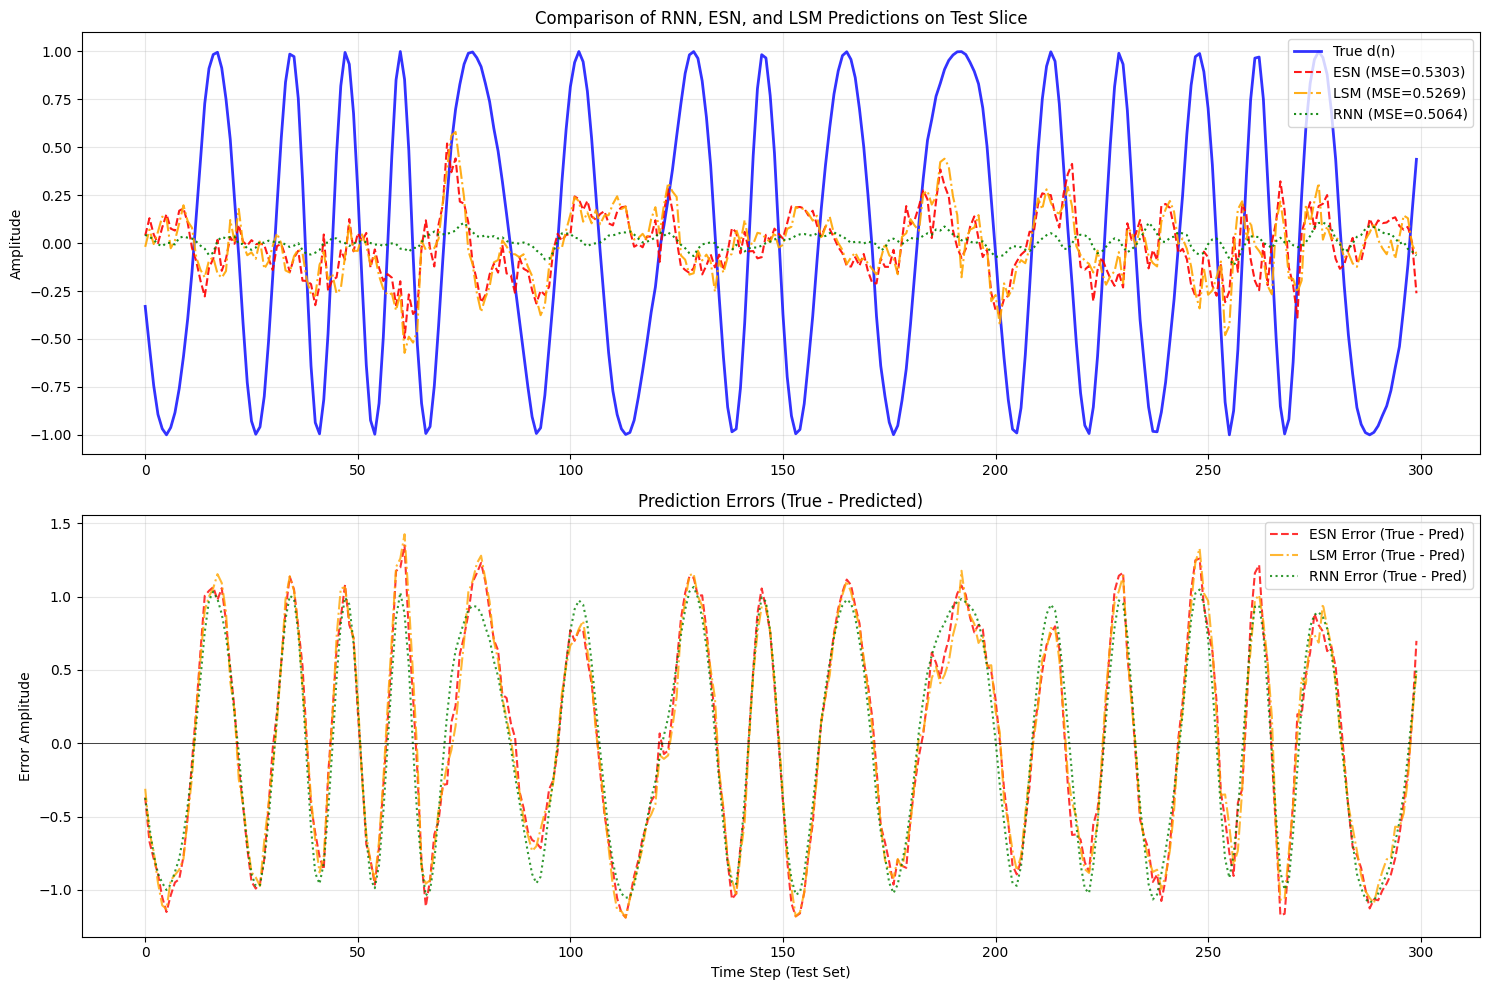


--- Final Comparison Table (on common test slice) ---
Model      | Test MSE    
-------------------------
ESN        | 0.530315    
LSM        | 0.526887    
RNN        | 0.506372    


In [ ]:
# Ensure all predictions are aligned for comparison.
# RNN prediction length: len(y_test_tensor) = test_length - lookback_steps
# ESN/LSM prediction length: len(d_test) = test_length
# To compare fairly, we predict ESN/LSM only on the u_test part relevant for RNN target.
# The RNN target is y_test_rnn which corresponds to d_test[lookback_steps:test_length]
# The RNN input is X_test_rnn which uses u_test[0:test_length-1] in lookback windows.
# The first RNN prediction corresponds to d_test[lookback_steps]
# So, to compare ESN/LSM prediction with RNN, we need ESN/LSM prediction on u_test[lookback_steps:test_length]

u_test_for_rnn_target = u_test[lookback_steps:test_length] # Input for RNN's first prediction onwards
d_test_for_comparison = d_test[lookback_steps:test_length] # Target for RNN and comparison slice

# Predict ESN and LSM on the specific input slice corresponding to RNN's target
y_pred_esn_for_comparison = esn.predict(u_test_for_rnn_target)
y_pred_lsm_for_comparison = lsm.predict(u_test_for_rnn_target)

# Now all predictions (y_pred_rnn, y_pred_esn_for_comparison, y_pred_lsm_for_comparison)
# and the target (d_test_for_comparison) have the same length: test_length - lookback_steps

print("\n--- Comparing Models on RNN Target Slice ---")
print(f"Comparing on {len(d_test_for_comparison)} test steps.")
print(f"ESN MSE on comparison slice: {mean_squared_error(d_test_for_comparison, y_pred_esn_for_comparison):.6f}")
print(f"LSM MSE on comparison slice: {mean_squared_error(d_test_for_comparison, y_pred_lsm_for_comparison):.6f}")
print(f"RNN MSE: {mse_rnn:.6f}")

# Plot comparison
plt.figure(figsize=(15, 10))

# Subplot 1: All Predictions vs True
plt.subplot(2, 1, 1)
time_points = range(len(d_test_for_comparison))
plt.plot(time_points[:300], d_test_for_comparison[:300], label='True d(n)', color='blue', linewidth=2, linestyle='-', alpha=0.8) # Plot true signal first
plt.plot(time_points[:300], y_pred_esn_for_comparison[:300], label=f'ESN (MSE={mean_squared_error(d_test_for_comparison, y_pred_esn_for_comparison):.4f})', color='red', linestyle='--', alpha=0.9)
plt.plot(time_points[:300], y_pred_lsm_for_comparison[:300], label=f'LSM (MSE={mean_squared_error(d_test_for_comparison, y_pred_lsm_for_comparison):.4f})', color='orange', linestyle='-.', alpha=0.9)
plt.plot(time_points[:300], y_pred_rnn[:300], label=f'RNN (MSE={mse_rnn:.4f})', color='green', linestyle=':', alpha=0.9)

plt.title('Comparison of RNN, ESN, and LSM Predictions on Test Slice')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Prediction Errors (Difference from True)
plt.subplot(2, 1, 2)
error_esn = d_test_for_comparison - y_pred_esn_for_comparison
error_lsm = d_test_for_comparison - y_pred_lsm_for_comparison
error_rnn = d_test_for_comparison - y_pred_rnn # y_pred_rnn already aligns with comparison slice

plt.plot(time_points[:300], error_esn[:300], label='ESN Error (True - Pred)', color='red', linestyle='--', alpha=0.8)
plt.plot(time_points[:300], error_lsm[:300], label='LSM Error (True - Pred)', color='orange', linestyle='-.', alpha=0.8)
plt.plot(time_points[:300], error_rnn[:300], label='RNN Error (True - Pred)', color='green', linestyle=':', alpha=0.8)

plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5) # Add zero line for reference
plt.title('Prediction Errors (True - Predicted)')
plt.xlabel('Time Step (Test Set)')
plt.ylabel('Error Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final comparison table
print("\n--- Final Comparison Table (on common test slice) ---")
print(f"{'Model':<10} | {'Test MSE':<12}")
print("-" * 25)
print(f"{'ESN':<10} | {mean_squared_error(d_test_for_comparison, y_pred_esn_for_comparison):<12.6f}")
print(f"{'LSM':<10} | {mean_squared_error(d_test_for_comparison, y_pred_lsm_for_comparison):<12.6f}")
print(f"{'RNN':<10} | {mse_rnn:<12.6f}")


--- Training Stabilized ESN (Reservoir Computing) ---
Stabilized ESN fitted with reg=0.0001, noise=0.005. Wout shape: (1, 152)
Stabilized ESN Test MSE: 0.520402


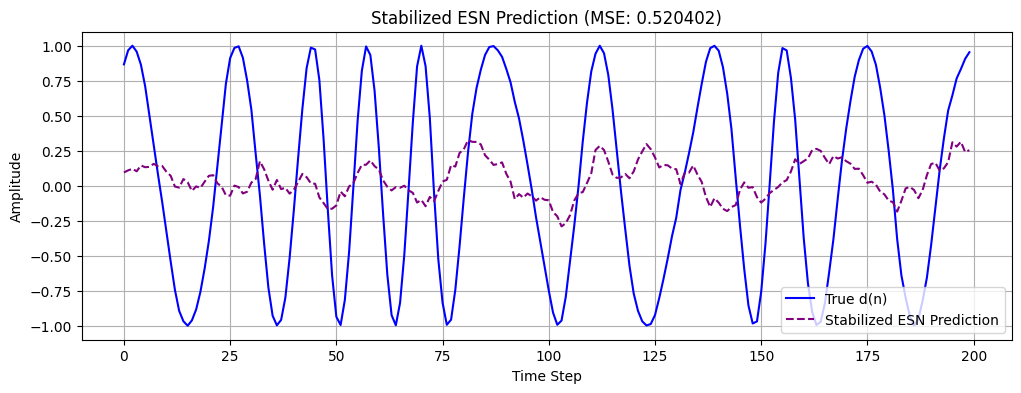

In [ ]:
# --- 7. Train Stabilized Reservoir Computing (Stabilized ESN) ---
# This version incorporates techniques for potentially better stability and accuracy:
# 1. Bias unit
# 2. Ridge Regression (Regularization)
# 3. Noise during sampling (training dynamics)
# 4. Sigmoid output inversion (collecting tanh^-1(d(n)) during training)

class StabilizedESN:
    def __init__(self, n_inputs, n_reservoir, n_outputs, spectral_radius=0.95,
                 input_scaling=1.0, reservoir_scaling=1.0, leak_rate=1.0,
                 regularization=1e-6, noise_level=0.001, random_state=45): # Different seed
        """
        Initializes the Stabilized Echo State Network with techniques for improved performance.

        Args:
            n_inputs (int): Number of input units.
            n_reservoir (int): Number of reservoir units.
            n_outputs (int): Number of output units.
            spectral_radius (float): Desired spectral radius of the reservoir weight matrix.
            input_scaling (float): Scaling factor for input weights.
            reservoir_scaling (float): Scaling factor for reservoir weights (after spectral radius adjustment).
            leak_rate (float): Leaking rate for the reservoir state update (0 < leak_rate <= 1).
            regularization (float): Regularization parameter (alpha) for Ridge Regression.
            noise_level (float): Standard deviation of noise added during sampling (training).
            random_state (int): Seed for random number generation.
        """
        self.n_inputs = n_inputs
        self.n_reservoir = n_reservoir
        self.n_outputs = n_outputs
        self.input_scaling = input_scaling
        self.reservoir_scaling = reservoir_scaling
        self.leak_rate = leak_rate
        self.regularization = regularization # For Ridge Regression
        self.noise_level = noise_level # For noise during sampling
        self.random_state = random_state

        np.random.seed(self.random_state)

        # Initialize reservoir weights W (NxN)
        W = np.random.rand(self.n_reservoir, self.n_reservoir) - 0.5
        eigenvalues, _ = np.linalg.eig(W)
        current_spectral_radius = np.max(np.abs(eigenvalues))
        W = (W / current_spectral_radius) * spectral_radius
        self.W = W * self.reservoir_scaling

        # Initialize input weights Win (NxK)
        Win = (np.random.rand(self.n_reservoir, self.n_inputs) - 0.5) * 2 * self.input_scaling
        self.Win = Win

        self.Wout = None
        self.x = np.zeros((self.n_reservoir, 1))

    def _update_state(self, u, y_prev=None, add_noise=False):
        """Updates the reservoir state, potentially with noise."""
        pre_activation = np.dot(self.W, self.x) + np.dot(self.Win, u)
        new_x = np.tanh(pre_activation)
        if self.leak_rate < 1.0:
            self.x = (1 - self.leak_rate) * self.x + self.leak_rate * new_x
        else:
            self.x = new_x

        # Add noise during sampling (training) as per qwe.pdf
        if add_noise:
            noise = np.random.normal(0, self.noise_level, size=self.x.shape)
            self.x += noise
        return self.x

    def fit(self, u_data, d_data, T0=0):
        """Trains the ESN using Ridge Regression and sigmoid output inversion."""
        T = u_data.shape[0]
        collected_states = []
        collected_targets = []

        self.x = np.zeros((self.n_reservoir, 1))

        for t in range(T):
            u_t = u_data[t].reshape(-1, 1)
            d_t = d_data[t].reshape(-1, 1)

            # Update state with noise during training (sampling)
            self._update_state(u_t, y_prev=None, add_noise=True)

            if t >= T0:
                # Collect [bias=1, input, reservoir_state] -> [1, K, N]
                current_state_concat = np.vstack([[[1.0]], u_t, self.x]) # Shape (K+N+1, 1)
                collected_states.append(current_state_concat.flatten())

                # Collect sigmoid-inverted target: tanh^-1(d(n))
                # Clip d_t to avoid numerical issues with tanh^-1
                d_clipped = np.clip(d_t, -0.99, 0.99)
                d_inv = np.arctanh(d_clipped)
                collected_targets.append(d_inv.flatten())

        M = np.array(collected_states) # Shape (T-T0, K+N+1)
        T_targets = np.array(collected_targets) # Shape (T-T0, L)

        # Use Ridge Regression
        try:
            # Calculate Wout_T for each output dimension separately for numerical stability
            Wout_T_parts = []
            for i in range(T_targets.shape[1]): # Iterate over output dimensions
                target_col = T_targets[:, i] # Shape (T-T0,)
                # M^T * M + alpha * I
                MtM_reg = M.T @ M + self.regularization * np.eye(M.shape[1])
                # (M^T * M + alpha * I)^-1 * M^T * target_col
                w_out_col = np.linalg.solve(MtM_reg, M.T @ target_col) # Shape (K+N+1,)
                Wout_T_parts.append(w_out_col)

            Wout_T = np.column_stack(Wout_T_parts) # Shape (K+N+1, L)
            self.Wout = Wout_T.T # Shape (L, K+N+1)
        except np.linalg.LinAlgError:
            print("Warning: Solving failed, falling back to regularized pseudoinverse.")
            MtM_reg = M.T @ M + self.regularization * np.eye(M.shape[1])
            M_pinv_reg = np.linalg.inv(MtM_reg) @ M.T # Regularized pseudoinverse
            Wout_T = M_pinv_reg @ T_targets
            self.Wout = Wout_T.T

        print(f"Stabilized ESN fitted with reg={self.regularization}, noise={self.noise_level}. Wout shape: {self.Wout.shape}")

    def predict(self, u_data, initial_state=None):
        """Predicts output using the trained readout."""
        if self.Wout is None:
            raise ValueError("Stabilized ESN must be fitted before prediction.")

        P = u_data.shape[0]
        predictions = np.zeros((P, self.n_outputs))

        if initial_state is not None:
            self.x = initial_state
        else:
            self.x = np.zeros((self.n_reservoir, 1))

        for t in range(P):
            u_t = u_data[t].reshape(-1, 1)
            # Update state WITHOUT noise during prediction
            self._update_state(u_t, y_prev=None, add_noise=False)
            # Use [bias=1, input, reservoir_state] for prediction
            state_concat = np.vstack([[[1.0]], u_t, self.x]) # Shape (K+N+1, 1)
            # Apply output weights
            y_t_raw = self.Wout @ state_concat # Shape (L, 1)
            # Apply final output activation (tanh) to get actual prediction
            y_t = np.tanh(y_t_raw)
            predictions[t] = y_t.flatten()

        return predictions


# --- Train Stabilized ESN ---
print("\n--- Training Stabilized ESN (Reservoir Computing) ---")
stabilized_esn = StabilizedESN(
    n_inputs=1,
    n_reservoir=150, # Slightly larger reservoir
    n_outputs=1,
    spectral_radius=0.85, # Slightly higher for potentially longer memory
    input_scaling=1.1,   # Slightly higher input scaling
    reservoir_scaling=1.0,
    leak_rate=0.95,       # Leaky integration might help with tracking
    regularization=1e-4, # Regularization
    noise_level=0.005,   # Add noise during training for stability
    random_state=45
)

stabilized_esn.fit(u_train, d_train, T0=T0)

# --- Test Stabilized ESN ---
y_pred_stabilized_esn = stabilized_esn.predict(u_test)

# Calculate MSE
mse_stabilized_esn = mean_squared_error(d_test, y_pred_stabilized_esn)
print(f"Stabilized ESN Test MSE: {mse_stabilized_esn:.6f}")

# Plot Stabilized ESN Results
plt.figure(figsize=(12, 4))
plt.plot(d_test[:200], label='True d(n)', color='blue')
plt.plot(y_pred_stabilized_esn[:200], label='Stabilized ESN Prediction', color='purple', linestyle='--')
plt.title(f'Stabilized ESN Prediction (MSE: {mse_stabilized_esn:.6f})')
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()